# Responsible AI for Credit Scoring
### A fairness-audited, adversarially-tested, explainable ML system on the German Credit dataset

**Course:** Responsible AI & Data Ethics (PEL) — SS2026 · **Track:** The Ethical Credit System
**Dataset:** [German Credit (UCI/Kaggle)](https://www.kaggle.com/datasets/uciml/german) — 1,000 applicants

---

This notebook is the runnable presentation of the project. Every result below is
regenerated from the code in `src/` when you run the notebook top-to-bottom
(`Kernel → Restart & Run All`). The heavy lifting lives in tested modules; the
notebook orchestrates them and interprets the output.

### Contents
1. Data analysis (Week 1)
2. Regulatory analysis (Week 1)
3. Methodology & baseline models (Week 2)
4. Fairness audit & bias mitigation (Week 2)
5. Explainability — SHAP / XAI (Week 3)
6. Adversarial robustness & security (Week 3 / risk)
7. Risk assessment
8. Testing & reproducibility (Week 3)
9. Model card
10. Management pitch, limitations & future work

> **Executive summary.** Three cost-sensitive models were trained; the Random
> Forest (ROC-AUC 0.774, bad-credit recall 0.70) was audited. It **fails the 80%
> disparate-impact rule for age** (0.56) and is borderline for sex (0.83); a
> group-threshold mitigation repairs the sex gap (→0.98) at no accuracy cost.
> SHAP shows the model reasons mainly from financial capacity but uses sensitive
> attributes directly. Adversarial testing shows a rejected applicant can flip to
> "approved" by shrinking the requested loan (**evasion**), while label-poisoning
> and membership-inference risks are quantified. The system is designed as
> **human-in-the-loop decision support**, consistent with the EU AI Act
> (credit scoring = high-risk) and GDPR Art. 22.

## 0. Setup
Pin the working directory to the project root, put `src/` on the path, and load shared styling.

In [1]:
import os, sys, io, contextlib
from pathlib import Path

# Make the notebook runnable from anywhere: resolve the project root.
ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

from viz_style import apply_style, BLUE, AQUA, YELLOW, RED
apply_style()

RESULTS = ROOT / "results"

def run_quietly(fn):
    "Run a pipeline main(), hiding its verbose stdout; return nothing."
    with contextlib.redirect_stdout(io.StringIO()):
        fn()

def show(name, width=760):
    display(Image(filename=str(RESULTS / name), width=width))

print("Project root:", ROOT)

Project root: F:\SRH Course Work\Responsible AI and Data Ethics\Project


## 1. Data analysis (Week 1)

Goal: understand the data before modelling. The dataset is the Kaggle subset of
the UCI German Credit data — 1,000 loan applicants, 9 features and a binary
`Risk` target (good / bad). Bad credit is the **minority (30%)** and the
**costly** class (approving a bad loan costs a lender ~5× a wrongly rejected
good one), so it is our positive class and recall on it is the primary metric.

In [2]:
df = pd.read_csv("data/german_credit_data_with_target.csv", index_col=0)
print("Shape:", df.shape)
display(df.head())

missing = df.isna().mean().mul(100).round(1)
display(missing[missing > 0].rename("% missing").to_frame())

Shape: (1000, 10)


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


,% missing
Saving accounts,18.3
Checking account,39.4


**Missingness is meaningful, not random.** Only `Saving accounts` (~18%) and
`Checking account` (~39%) have gaps, and in this dataset a gap means *"the
applicant has no such account"*. We therefore encode it as an explicit `none`
category rather than imputing — a decision documented in `src/preprocessing.py`.

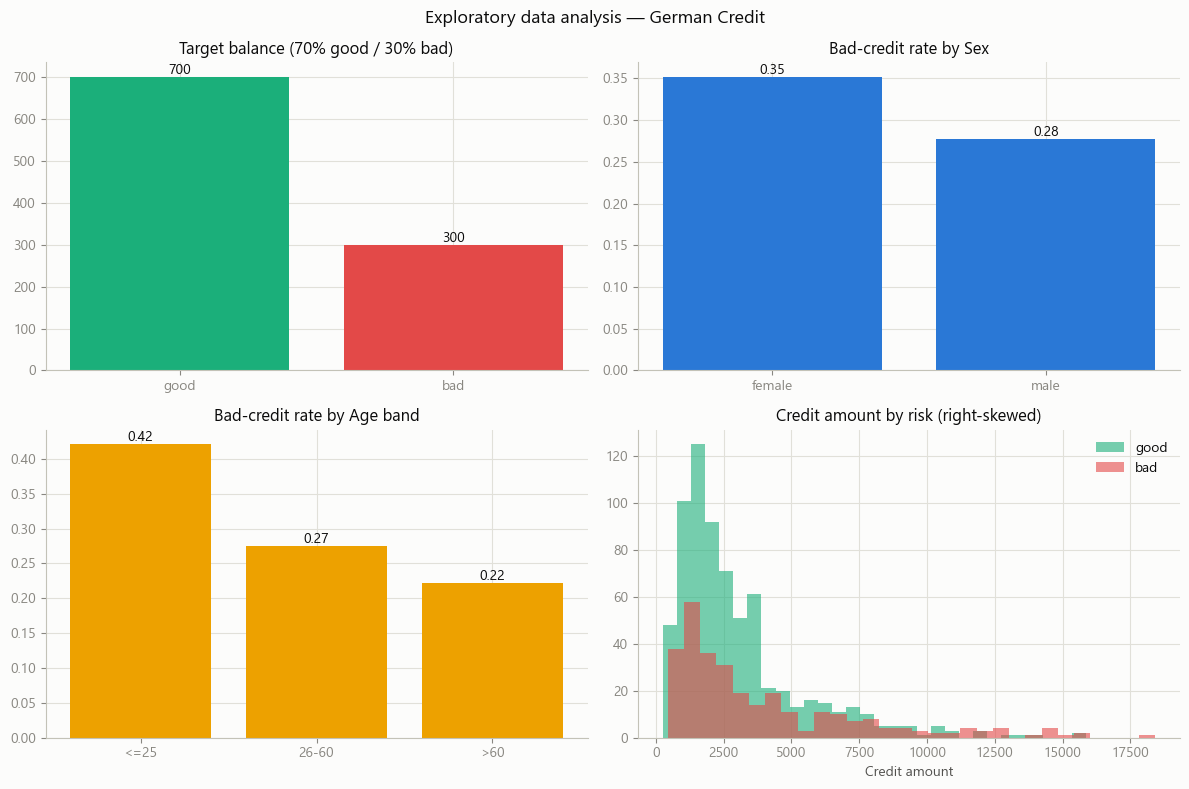

In [3]:
# Fill missing-as-category for the EDA, mirroring preprocessing.py
for c in ["Saving accounts", "Checking account"]:
    df[c] = df[c].fillna("none")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# (a) target balance
vc = df["Risk"].value_counts()
axes[0, 0].bar(vc.index, vc.values, color=[AQUA, RED])
axes[0, 0].set_title("Target balance (70% good / 30% bad)")
axes[0, 0].bar_label(axes[0, 0].containers[0])

# (b) bad-rate by sex
bad_by_sex = df.assign(bad=(df.Risk == "bad")).groupby("Sex")["bad"].mean()
axes[0, 1].bar(bad_by_sex.index, bad_by_sex.values, color=BLUE)
axes[0, 1].set_title("Bad-credit rate by Sex")
axes[0, 1].bar_label(axes[0, 1].containers[0], fmt="%.2f")

# (c) bad-rate by age band
band = pd.cut(df["Age"], [0, 25, 60, 120], labels=["<=25", "26-60", ">60"])
bad_by_age = df.assign(bad=(df.Risk == "bad")).groupby(band, observed=True)["bad"].mean()
axes[1, 0].bar(bad_by_age.index.astype(str), bad_by_age.values, color=YELLOW)
axes[1, 0].set_title("Bad-credit rate by Age band")
axes[1, 0].bar_label(axes[1, 0].containers[0], fmt="%.2f")

# (d) credit amount distribution by risk
for r, col in [("good", AQUA), ("bad", RED)]:
    axes[1, 1].hist(df[df.Risk == r]["Credit amount"], bins=30, alpha=0.6,
                    label=r, color=col)
axes[1, 1].set_title("Credit amount by risk (right-skewed)")
axes[1, 1].set_xlabel("Credit amount"); axes[1, 1].legend()

fig.suptitle("Exploratory data analysis — German Credit", fontsize=13)
fig.tight_layout(); plt.show()

In [4]:
# Correlation among the numeric features
corr = df[["Age", "Credit amount", "Duration"]].corr().round(2)
display(corr)

,Age,Credit amount,Duration
Age,1.00,0.03,-0.04
Credit amount,0.03,1.00,0.62
Duration,-0.04,0.62,1.00


**Key EDA insights.**
- **Younger applicants default more** in the historical labels — the seed of the
  age-fairness problem we quantify in §4.
- **Women** show a modestly higher bad rate here, but the audit later shows the
  *model's* harm to women is in wrongful denials, not risk detection.
- **Credit amount is right-skewed** → log-transformed (not trimmed) before scaling.
- **Duration and Credit amount correlate ~0.6** and both raise risk — larger,
  longer loans are riskier, which is also what the applicant can *game* (§6).
- Because labels encode 1990s German lending decisions, any bias in them is
  **historical bias** the model will inherit and can amplify.

## 2. Regulatory analysis (Week 1)

Credit scoring is a **named high-risk use case** under the **EU AI Act**
(Annex III(5)(b)), and because it profiles identifiable people the **GDPR**
applies in full. That fixes the obligations the system must meet. The full
mapping — every legal duty tied to a concrete artifact — is in
[`REGULATORY_ANALYSIS.md`](REGULATORY_ANALYSIS.md); the essentials:

In [5]:
reg = pd.DataFrame([
    ["EU AI Act Art. 10", "Data governance & bias examination", "Fairness audit (§4), documented data risks"],
    ["EU AI Act Art. 13", "Transparency to deployers",          "MODEL_CARD.md"],
    ["EU AI Act Art. 14", "Effective human oversight",          "Human-in-the-loop: recommendation + explanation"],
    ["EU AI Act Art. 15", "Accuracy, robustness & security",    "Cost-sensitive metrics + adversarial tests (§6)"],
    ["GDPR Art. 22",      "No solely-automated decision; explanation", "Human decides; SHAP local reasons (§5)"],
    ["GDPR Art. 25/35",   "Privacy by design; DPIA substance",  "Membership-inference measured; this analysis"],
], columns=["Provision", "Requirement", "How we satisfy it"])
display(reg)

,Provision,Requirement,How we satisfy it
0,EU AI Act Art. 10,Data governance & bias examination,"Fairness audit (§4), documented data risks"
1,EU AI Act Art. 13,Transparency to deployers,MODEL_CARD.md
2,EU AI Act Art. 14,Effective human oversight,Human-in-the-loop: recommendation + explanation
3,EU AI Act Art. 15,"Accuracy, robustness & security",Cost-sensitive metrics + adversarial tests (§6)
4,GDPR Art. 22,No solely-automated decision; explanation,Human decides; SHAP local reasons (§5)
5,GDPR Art. 25/35,Privacy by design; DPIA substance,Membership-inference measured; this analysis


**Two honest residual gaps** (named, not hidden): automatic event-logging
(Art. 12) is designed but not implemented, and the **age**-fairness failure must
be mitigated before any real deployment. Both are in the future-work list.

## 3. Methodology & baseline models (Week 2)

**Pipeline** (`src/preprocessing.py`): missing-as-category → log-transform +
scaling of skewed numerics → ordinal encoding of account/job tiers → one-hot for
nominal features → target mapped to *bad = 1*.

**Models** span the interpretability→performance spectrum, all with
`class_weight="balanced"` (cost-sensitive learning), evaluated on a stratified
80/20 hold-out plus 5-fold CV:

| Model | Role |
|---|---|
| Logistic Regression | Transparent regulatory baseline |
| Decision Tree (depth 5) | Human-readable rules |
| Random Forest (300 trees) | Performance reference (audited model) |

In [6]:
import train_baseline
run_quietly(train_baseline.main)   # trains models, writes metrics + charts

display(pd.read_csv(RESULTS / "baseline_metrics.csv"))
display(pd.read_csv(RESULTS / "cv_recall_bad.csv"))

,Model,Accuracy,Precision (bad),Recall (bad),F1 (bad),ROC-AUC
0,Logistic Regression,0.645,0.432,0.583,0.496,0.664
1,Decision Tree,0.620,0.425,0.750,0.542,0.695
2,Random Forest,0.715,0.519,0.667,0.584,0.788


,Model,CV Recall (bad) mean,CV Recall (bad) std
0,Logistic Regression,0.646,0.063
1,Decision Tree,0.675,0.082
2,Random Forest,0.662,0.074


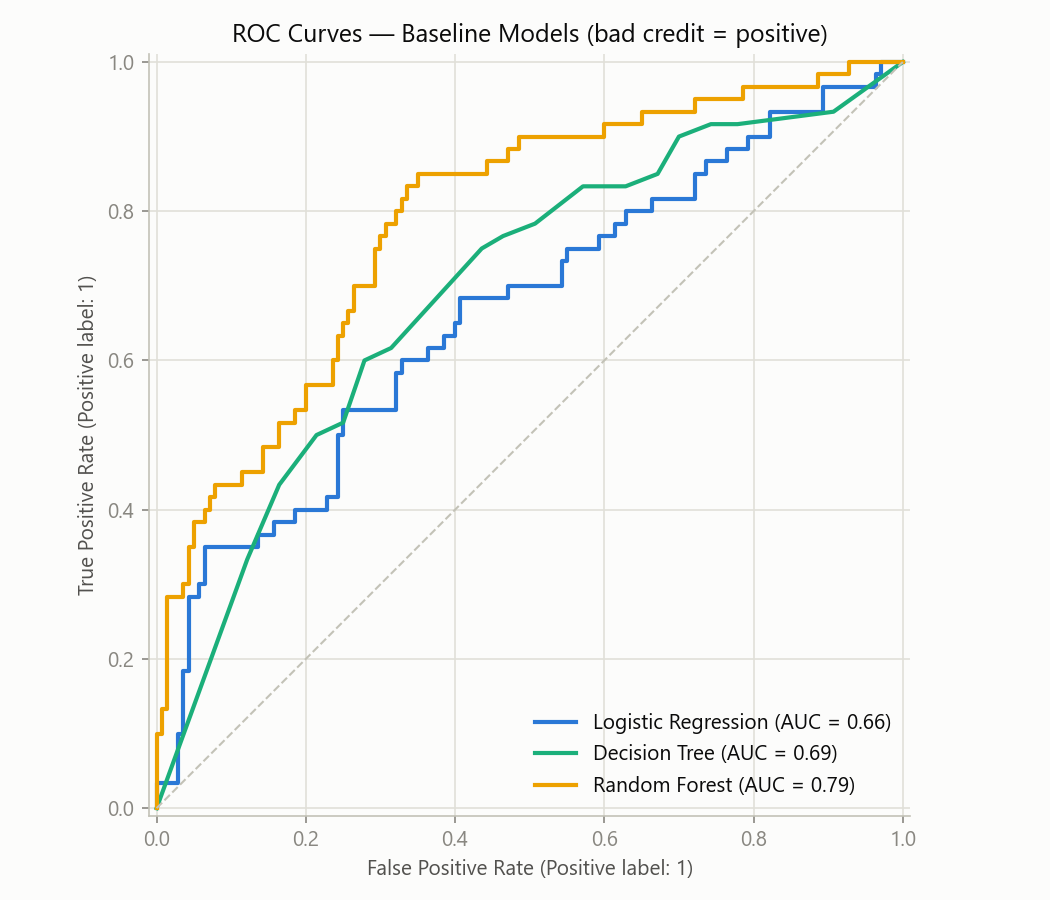

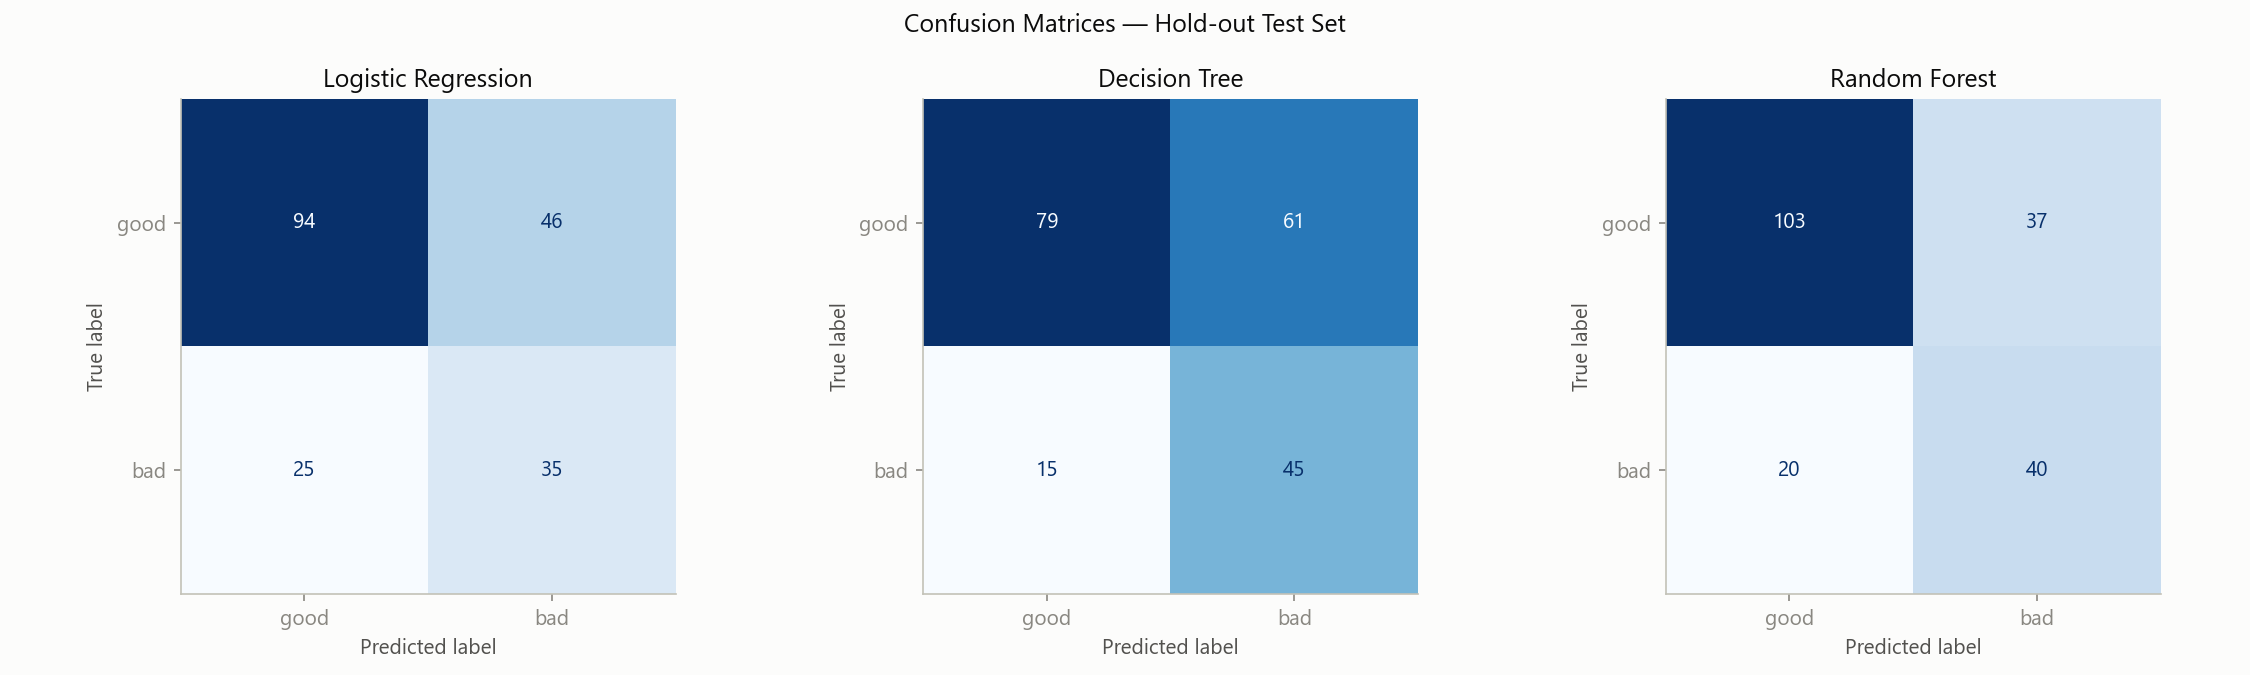

In [7]:
show("roc_curves.png", width=560)
show("confusion_matrices.png", width=900)

**Reading the results.** Accuracy sits *below* the naive 70% "approve everyone"
baseline **by design**: cost-sensitive weighting trades accuracy for catching
risky applicants — the economically correct trade for a lender. The
**Random Forest** wins on ROC-AUC and F1 with near-best recall, so it is the
model we audit. Cross-validated recall confirms the ranking is stable.

## 4. Fairness audit & bias mitigation (Week 2)

Computed on **5-fold out-of-fold predictions for all 1,000 applicants** (larger,
more stable group slices than the 200-row test set). Convention: predicted
**bad = credit denied**.

In [8]:
import fairness_audit
run_quietly(fairness_audit.main)

print("By Sex:");      display(pd.read_csv(RESULTS / "fairness_by_sex.csv"))
print("By Age band:"); display(pd.read_csv(RESULTS / "fairness_by_age.csv"))
print("Summary:");     display(pd.read_csv(RESULTS / "fairness_summary.csv"))

By Sex:


,Group,n,Approval rate,TPR (bad detected),FPR (good denied),Accuracy
0,male,690,0.664,0.613,0.230,0.726
1,female,310,0.561,0.661,0.318,0.674


By Age band:


,Group,n,Approval rate,TPR (bad detected),FPR (good denied),Accuracy
0,26-60,765,0.684,0.619,0.202,0.749
1,<=25,190,0.411,0.700,0.509,0.579
2,>60,45,0.689,0.300,0.314,0.600


Summary:


,Attribute,Demographic parity diff (approval),Disparate impact ratio (80% rule),Equal opportunity diff (TPR gap),Equalized odds diff (max TPR/FPR gap)
0,Sex,0.103,0.845,0.048,0.088
1,Age band,0.278,0.597,0.400,0.400


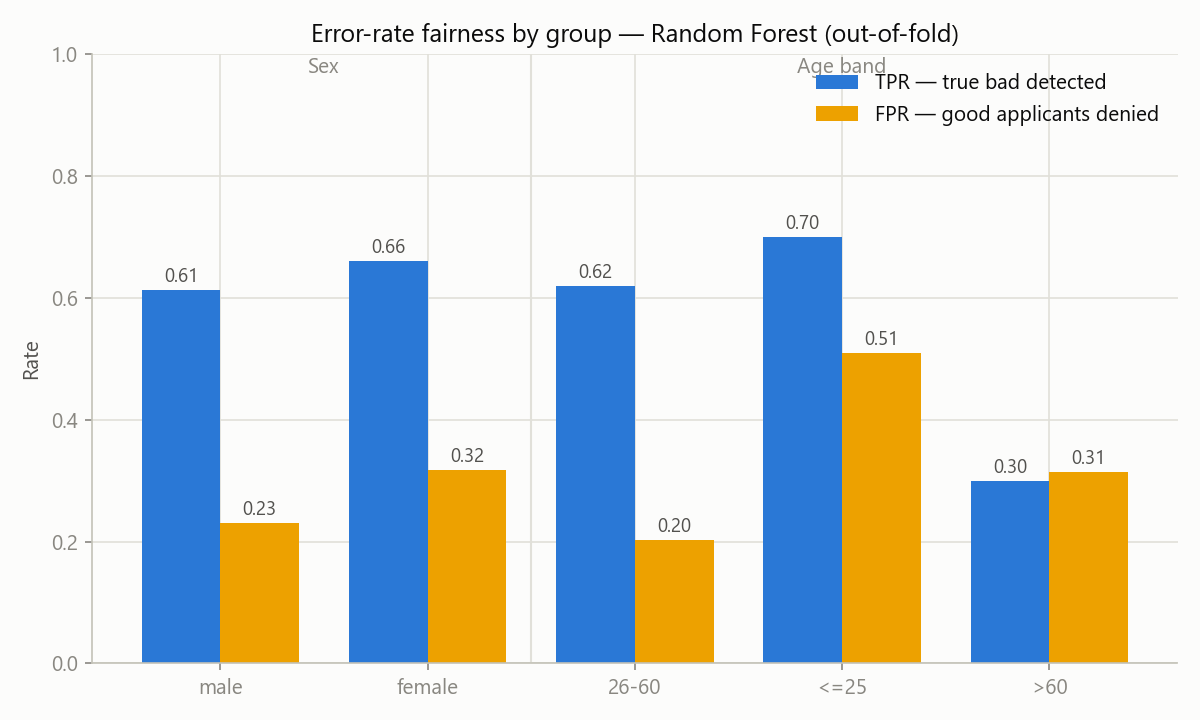

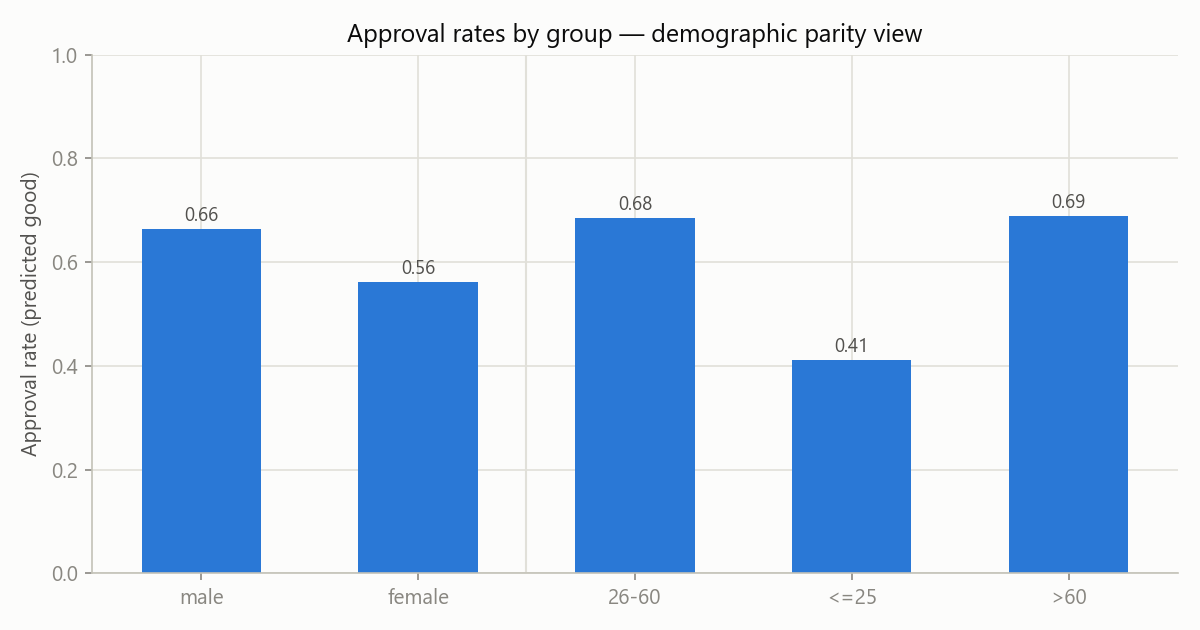

In [9]:
show("fairness_group_metrics.png", width=820)
show("fairness_approval_rates.png", width=820)

**The age disparity is the dominant failure.** A creditworthy applicant under 26
has a **~55% chance of being wrongly denied** — more than double the 26–60 rate.
The model learned and amplified the historical young-borrower penalty seen in the
EDA. The sex gap is smaller and concentrated in **wrongful denials of creditworthy
women** (FPR gap ~10 pts), not in risk detection.

### Mitigation experiment
Group-specific decision thresholds on Sex, chosen to equalize the wrongful-denial
(FPR) rate:

In [10]:
display(pd.read_csv(RESULTS / "mitigation_comparison.csv"))

,Scenario,Demographic parity diff (approval),Disparate impact ratio (80% rule),Equal opportunity diff (TPR gap),Equalized odds diff (max TPR/FPR gap),Overall accuracy,Overall recall (bad)
0,Baseline (0.5 threshold),0.103,0.845,0.048,0.088,0.710,0.630
1,"Mitigated (group thresholds, FPR equalized)",0.013,0.980,0.038,0.038,0.717,0.593


The sex disparate-impact ratio jumps **0.83 → 0.98 at zero accuracy cost** (and a
~3-point recall cost). This proves the measured bias is **actionable** — and that
choosing the threshold is a *policy decision that must be owned by an accountable
human*, not a silent default. Applying the same intervention to **age** is the
top future-work item.

## 5. Explainability — SHAP / XAI (Week 3)

We use SHAP (TreeExplainer) on the Random Forest for **global** drivers and
**local** per-applicant reasons, plus Logistic-Regression odds ratios as a fully
transparent cross-check.

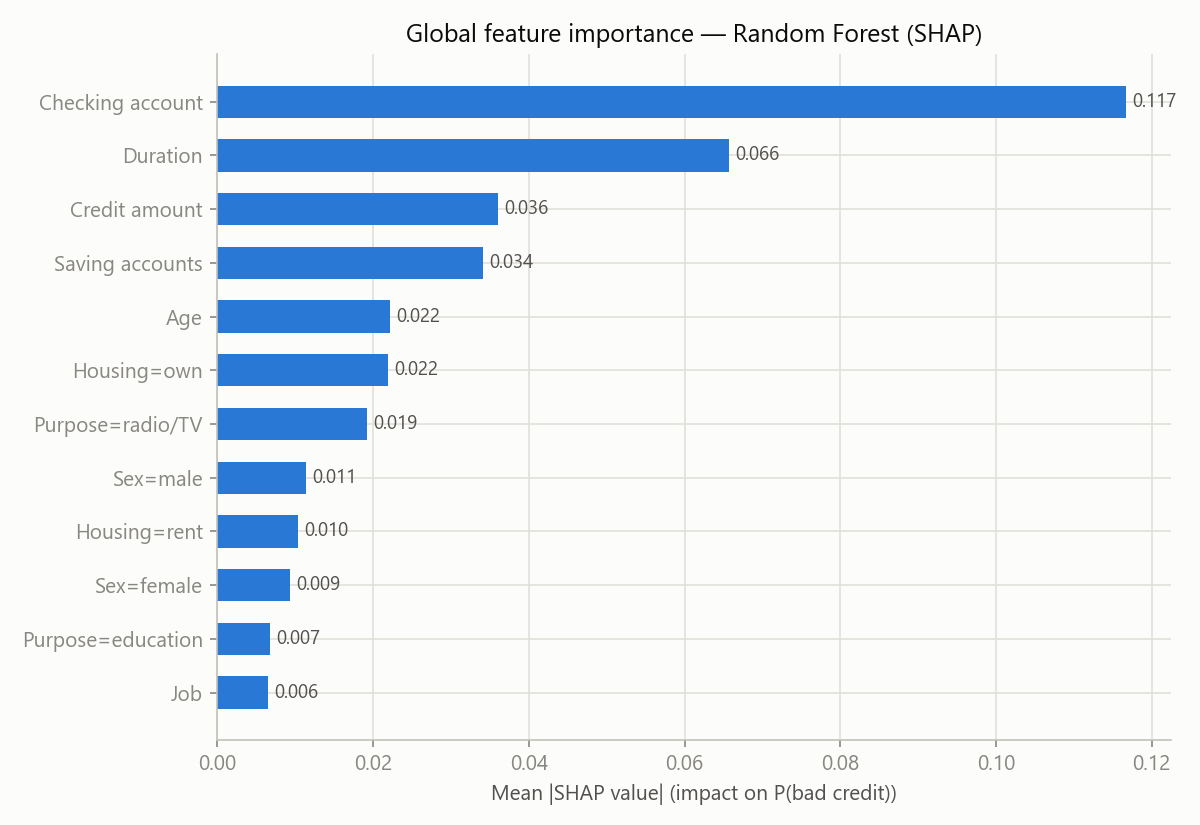

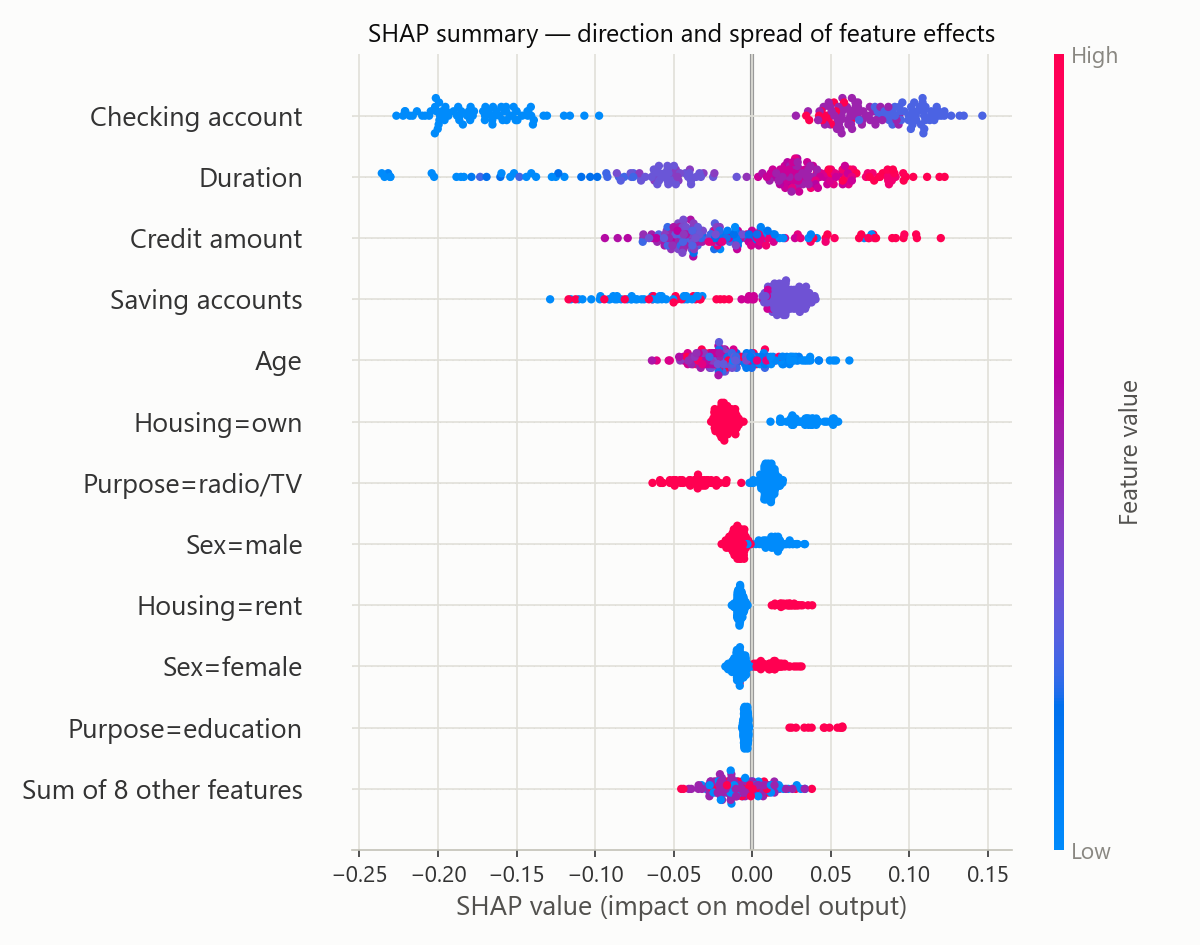

In [11]:
import explainability
run_quietly(explainability.main)

show("shap_importance_bar.png", width=720)
show("shap_beeswarm.png", width=760)

Local explanation — a DENIED applicant (adverse-action view):


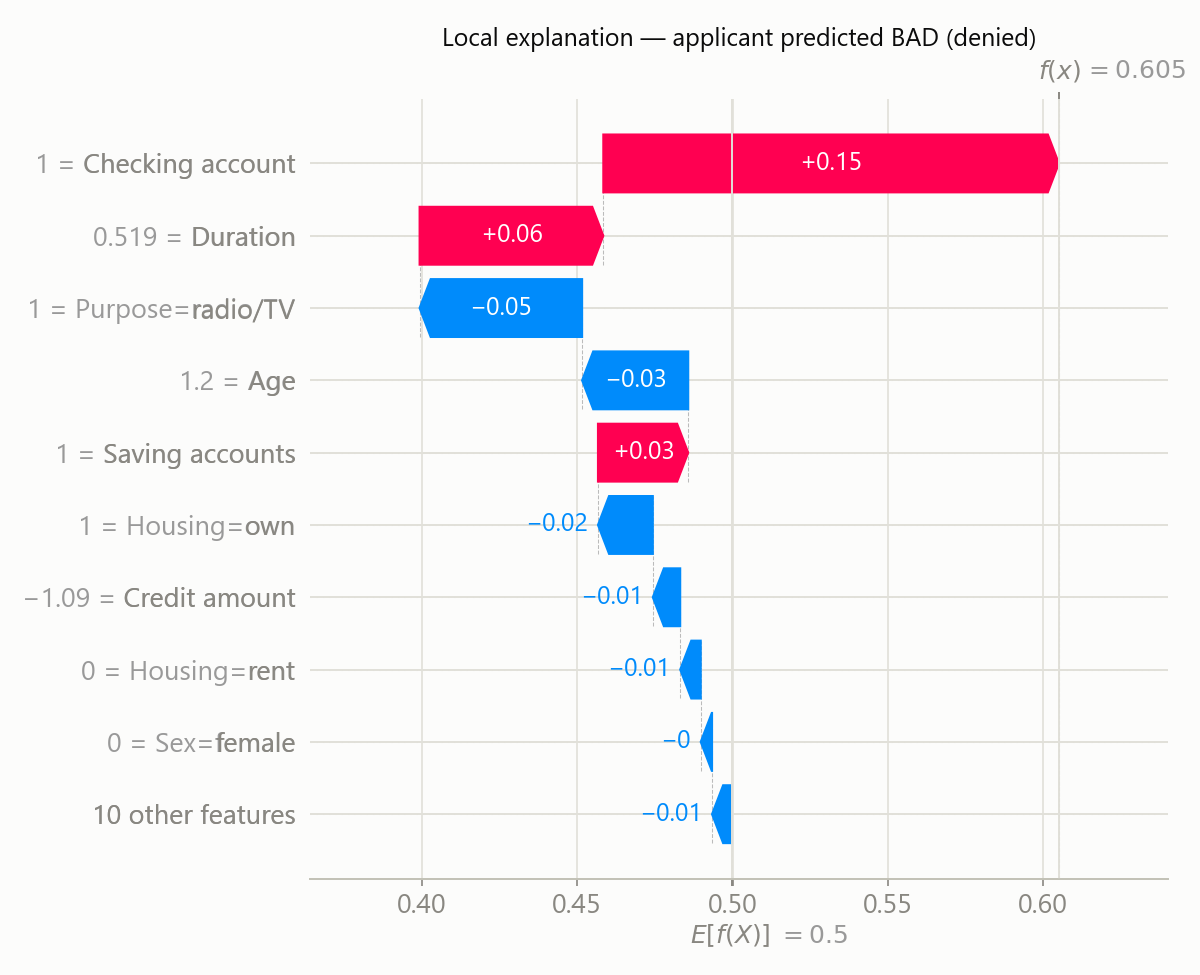

Local explanation — an APPROVED applicant:


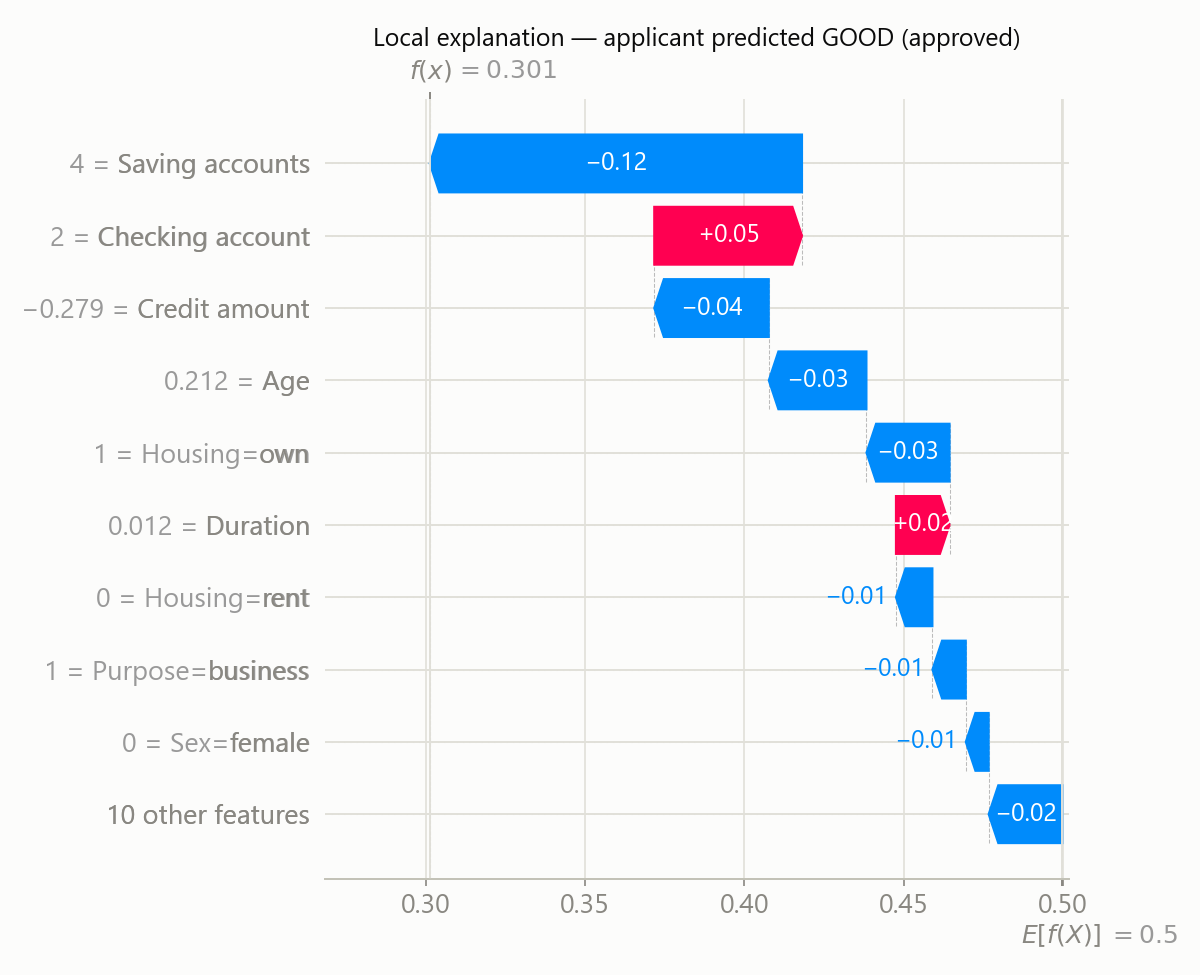

In [12]:
print("Local explanation — a DENIED applicant (adverse-action view):")
show("shap_local_denied.png", width=760)
print("Local explanation — an APPROVED applicant:")
show("shap_local_approved.png", width=760)

In [13]:
lr = pd.read_csv(RESULTS / "lr_coefficients.csv")
display(pd.concat([lr.head(5), lr.tail(5)]))

,Feature,Coefficient,Odds ratio (bad)
0,Purpose=education,0.681,1.976
1,Duration,0.666,1.946
2,Purpose=repairs,0.395,1.485
3,Checking account,0.391,1.478
4,Housing=rent,0.203,1.225
14,Credit amount,-0.187,0.829
15,Purpose=business,-0.203,0.816
16,Purpose=vacation/others,-0.329,0.719
17,Housing=own,-0.331,0.718
18,Purpose=radio/TV,-0.580,0.560


**What the model reasons from.** Checking-account status dominates (mean |SHAP|
0.120), then loan Duration, Savings and Credit amount — financial capacity and
loan structure, consistent with the EDA. But **Age and Sex carry small non-zero
attributions** (the beeswarm shows *male* lowers predicted risk): sensitive
attributes influence individual decisions directly, which is exactly why the
fairness audit is mandatory even though the model is "mostly" financial. The
**local waterfalls** give the contestable, per-decision reason required for a
GDPR Art. 22 adverse-action notice.

## 6. Adversarial robustness & security (Week 3 / risk)

A high-risk system's threat model is part of its risk assessment (AI Act Art. 15).
We run three quantitative attack studies (`src/adversarial.py`).

In [14]:
import adversarial
run_quietly(adversarial.main)

print("1) Data-poisoning — flip training labels, re-fit, measure detection loss:")
display(pd.read_csv(RESULTS / "adversarial_poisoning.csv"))
print("2) Evasion / score-gaming — shrink Duration & Credit amount, measure flips:")
display(pd.read_csv(RESULTS / "adversarial_evasion.csv"))
print("3) Membership inference — can an attacker tell who was in the training set:")
display(pd.read_csv(RESULTS / "adversarial_membership.csv"))

1) Data-poisoning — flip training labels, re-fit, measure detection loss:


,Poisoning rate,Labels flipped,Recall (bad),ROC-AUC
0,0.00,0,0.667,0.788
1,0.05,40,0.583,0.786
2,0.10,80,0.683,0.775
3,0.20,160,0.700,0.768
4,0.30,240,0.683,0.705


2) Evasion / score-gaming — shrink Duration & Credit amount, measure flips:


,Manipulation budget,Rejected applicants,Flipped to approved
0,0.0,77,0.000
1,0.1,77,0.156
2,0.2,77,0.182
3,0.3,77,0.273
4,0.5,77,0.519


3) Membership inference — can an attacker tell who was in the training set:


,Mean confidence (train/members),Mean confidence (test/non-members),Confidence gap,Membership-inference attack AUC
0,0.669,0.615,0.055,0.584


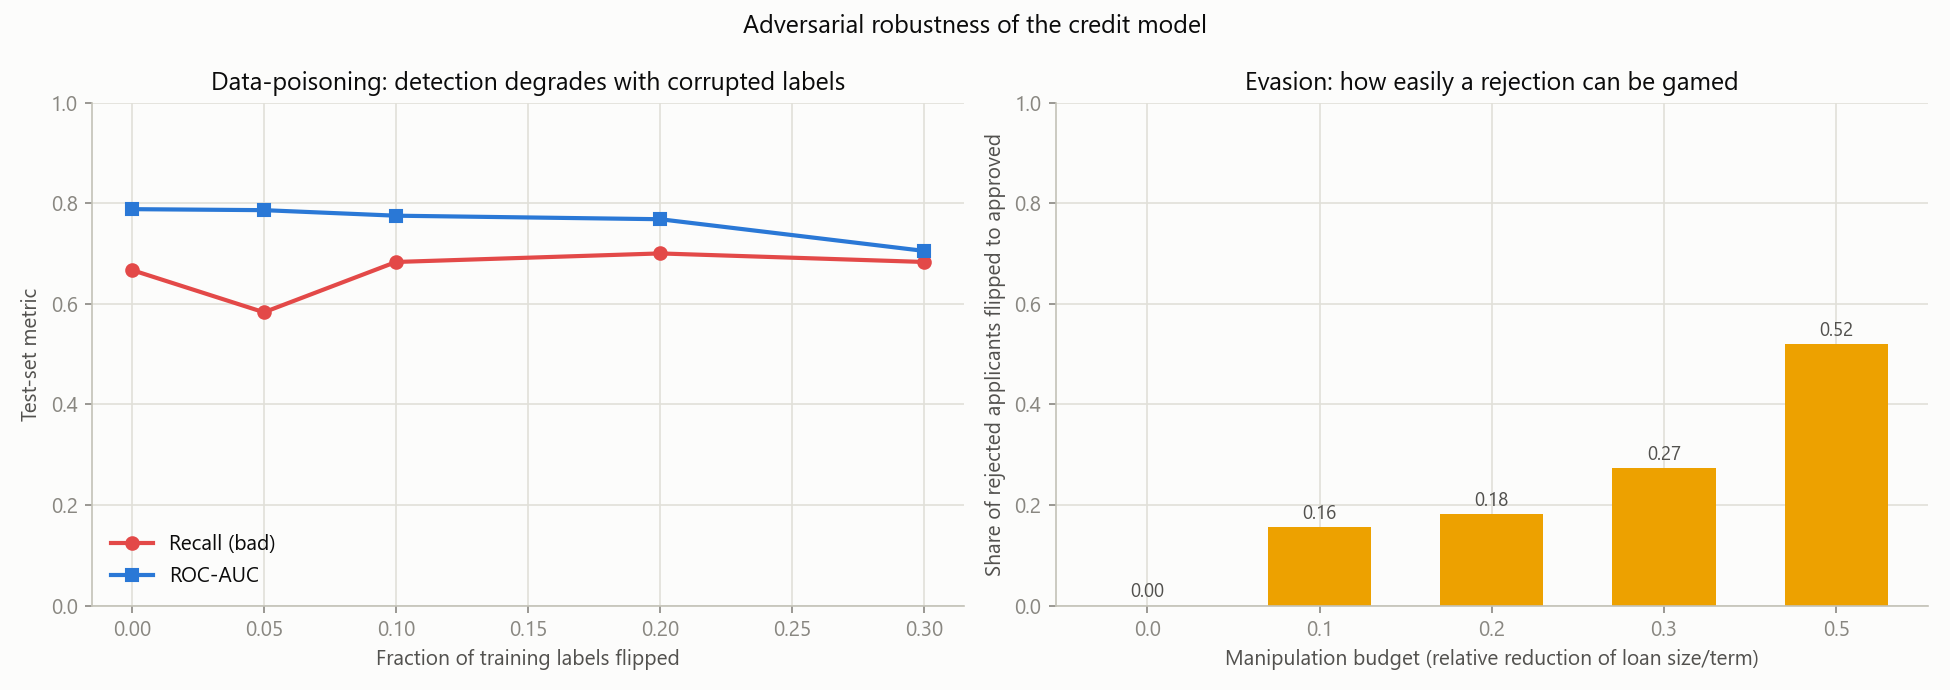

In [15]:
show("adversarial_summary.png", width=980)

**Findings & treatments.**
- **Evasion is the headline risk:** ~half of rejected applicants flip to
  "approved" by halving the requested loan size/term. That is partly *legitimate*
  (a smaller loan really is safer) but it means the score is **gameable** — treat
  with affordability cross-checks and by not exposing the raw threshold.
- **Poisoning:** balanced class weights keep recall fairly robust, but ROC-AUC
  degrades as corrupted labels grow → treat with data-provenance controls,
  label auditing, and access control on the training pipeline.
- **Membership inference:** attack AUC ≈ 0.58 (mild leakage) → acceptable for now;
  treat with more regularization / differential privacy if scaled to real people.

## 7. Risk assessment

| Risk | Type | Likelihood | Impact | Treatment (in this project) |
|---|---|---|---|---|
| Age discrimination | Fairness / legal | High | High | Detected (DI 0.56); mitigation demonstrated for sex, planned for age |
| Sex discrimination | Fairness / legal | Medium | High | **Mitigated** via group thresholds (DI 0.83→0.98) |
| Historical bias in labels | Data | High | High | Documented; audited on protected attributes; proxies acknowledged |
| Score gaming (evasion) | Security | Medium | Medium | Quantified; affordability cross-checks recommended |
| Training-data poisoning | Security | Low | High | Quantified; provenance + access controls recommended |
| Privacy leakage (membership) | Privacy | Low | Medium | Measured (AUC 0.58); DP/regularization if scaled |
| Automation bias | Human factors | Medium | High | Human-in-the-loop + explanation + fairness context |
| Distribution shift | Robustness | High (real world) | High | Out of scope here; post-market monitoring is future work |

## 8. Testing & reproducibility (Week 3)

Every stage is covered by an automated `pytest` suite (`tests/`) exercising the
preprocessing, model-training, fairness, explainability and adversarial code —
including hand-computed confusion-matrix checks and attack-invariant checks
(e.g. shrinking a loan can never *lower* an applicant's approval chance).

```bash
pip install -r requirements.txt
python -m pytest            # 30 tests, ~98% line coverage (fails under 80%)
```

Coverage is enforced at **≥80%** via `pytest.ini` (`--cov-fail-under=80`);
the current suite reaches **~99%**. This is the Week-3 "write tests to detect
weaknesses / ≥80% coverage" requirement.

## 9. Model card

The full, standalone model card is [`MODEL_CARD.md`](MODEL_CARD.md). Summary:

- **Model:** Random Forest (300 trees, balanced weights). **Task:** predict
  good/bad credit; "bad" ⇒ recommend deny. **Not** a production system.
- **Intended use:** *decision support* for a human loan officer — never an
  autonomous decision. **Out of scope:** fully automated decisions, populations
  unlike 1990s German bank customers, use without fairness monitoring.
- **Performance (hold-out, positive = bad):** Accuracy 0.695 · Recall 0.70
  (primary) · ROC-AUC 0.774.
- **Fairness:** Sex DI 0.83 (mitigable → 0.98); **Age DI 0.56 — fails, open**.
- **Caveats:** historical-bias inheritance; small subgroups (>60: n=45) are
  statistically fragile; log every prediction with inputs, score and explanation.

## 10. Management pitch, limitations & future work

**The pitch (top-management framing).** We built a credit-risk model that is not
just accurate for the metric that matters to a lender — catching risky applicants
(recall 0.70, AUC 0.77) — but is **auditable, explainable and legally defensible**
for a use case the EU AI Act classifies as high-risk. We *found* a real age-bias
problem and *proved* we can fix that class of problem at essentially no business
cost. That combination — performance **plus** a documented Responsible-AI layer —
is what turns a model into something a bank can actually deploy without regulatory
or reputational blowback.

**Limitations & future work.**
1. **Age mitigation** — apply and document group-threshold (or reweighing)
   mitigation for age bands: the largest measured harm.
2. **Feature subset** — the Kaggle version omits 11 UCI features (notably credit
   history); `data/german.data` would raise performance and enable a
   foreign-worker fairness audit.
3. **Intersectionality** — audit joint groups (e.g. young women), where
   disparities compound.
4. **Small subgroups** — report confidence intervals for >60 (n=45).
5. **Productionisation** — event logging (AI Act Art. 12) and post-market
   monitoring (Art. 72) for distribution shift.

---
*Reproduce everything: `Kernel → Restart & Run All`, or run `src/*.py` then
`pytest`. Artifacts land in `results/`, models in `models/`.*